In [2]:
!uv pip install matplotlib

Resolved 11 packages in 274ms                                        
░░░░░░░░░░░░░░░░░░░░ [0/5] Installing wheels...                                 warning: Failed to hardlink files; falling back to full copy. This may lead to degraded performance.
         If the cache and target directories are on different filesystems, hardlinking may not be supported.
         If this is intentional, set `export UV_LINK_MODE=copy` or use `--link-mode=copy` to suppress this warning.
Installed 5 packages in 1.86s                               
 + contourpy==1.3.3
 + cycler==0.12.1
 + fonttools==4.60.1
 + kiwisolver==1.4.9
 + matplotlib==3.10.7


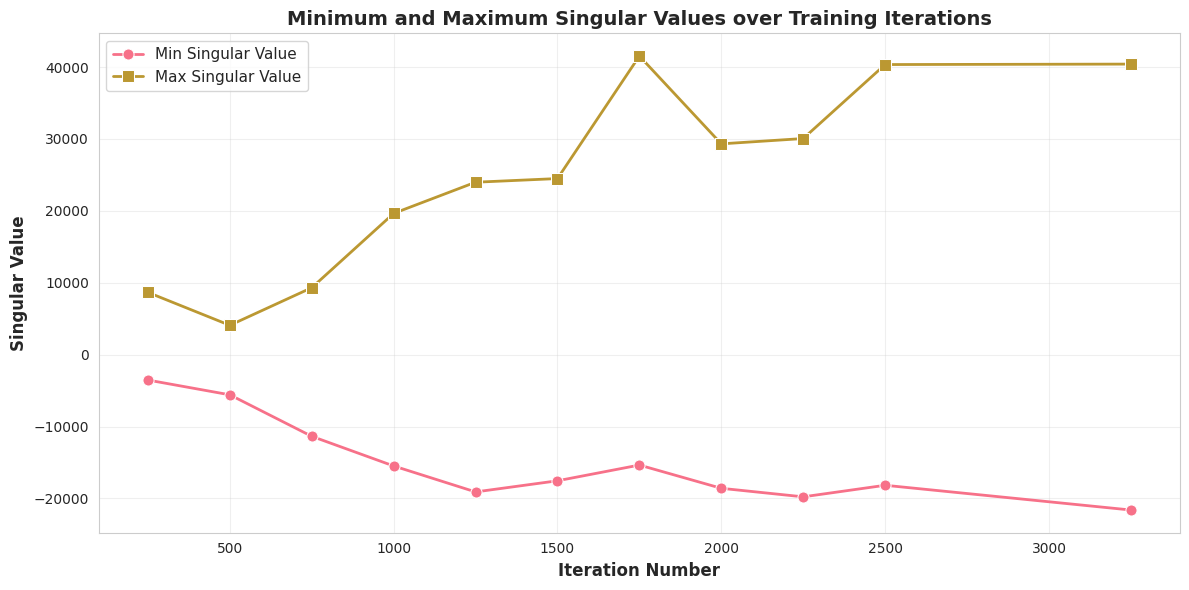

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read your CSV file
df = pd.read_csv('hessian_eigenvalues.csv')

# Set seaborn style
sns.set_style("whitegrid")
sns.set_palette("husl")

# Create figure
plt.figure(figsize=(12, 6))

# Plot both curves
sns.lineplot(data=df, x='iter_num', y='min_sv', marker='o', linewidth=2, markersize=8, label='Min Singular Value')
sns.lineplot(data=df, x='iter_num', y='max_sv', marker='s', linewidth=2, markersize=8, label='Max Singular Value')

# Customize the plot
plt.xlabel('Iteration Number', fontsize=12, fontweight='bold')
plt.ylabel('Singular Value', fontsize=12, fontweight='bold')
plt.title('Minimum and Maximum Singular Values over Training Iterations', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save and show
plt.savefig('singular_values_plot.png', dpi=300, bbox_inches='tight')
plt.show()


Best validation loss for each (optimizer, batch_size) across all learning rates:
        optimizer  batch_size learning_rate  best_val_loss  best_epoch
0         AdaGrad         128        0.0001       2.530987        4750
14        AdaGram         128          0.01       1.518688        4750
26          AdamW         128          0.01       1.463453        2500
38  MuonWithAdamW         128          0.01       1.481951        1000
29          AdamW         256         0.001       1.471426         750
18        AdaGram         256          0.01       1.494969        5000
42  MuonWithAdamW         256          0.01       1.476117         500
4         AdaGrad         256        0.0001       2.530973        4250
22        AdaGram         512          0.01       1.491378        3250
8         AdaGrad         512        0.0001       2.527876        4750
34          AdamW         512          0.01       1.472841        1000
46  MuonWithAdamW         512          0.01       1.498404         

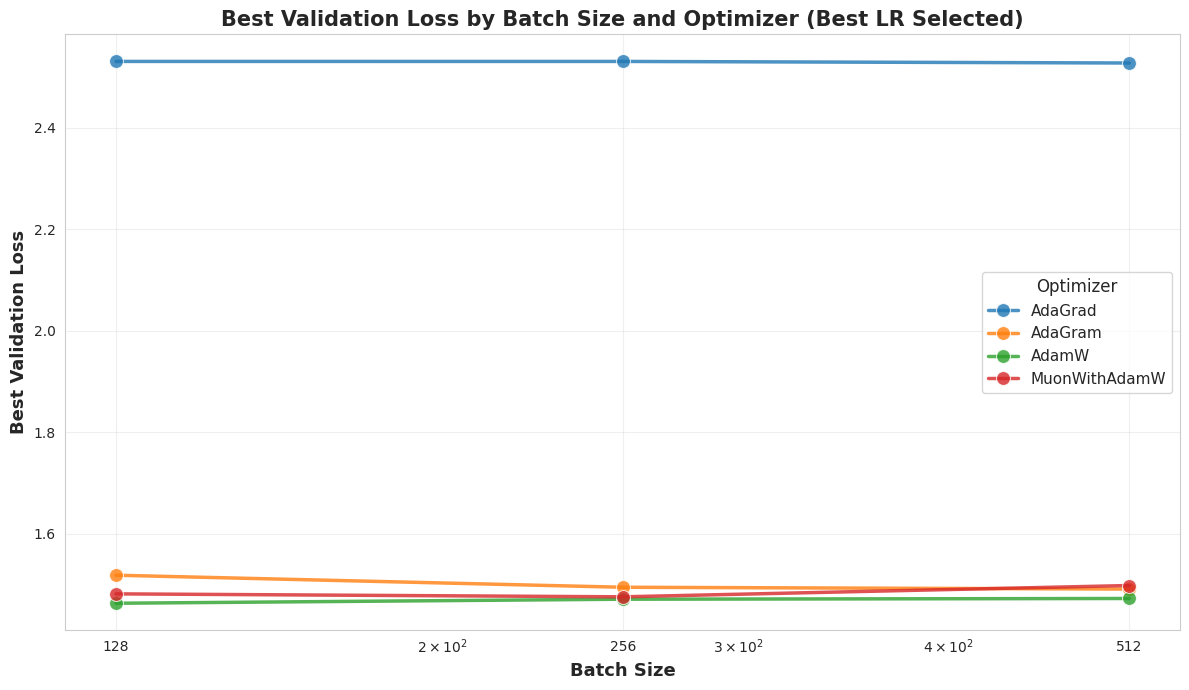

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import re

# Read all CSV files from the CSVS folder
csv_files = glob.glob('csvs/out-*.csv')

# Read and combine all CSV files
results = []
for file in csv_files:
    df = pd.read_csv(file)
    
    # Extract optimizer info from filename
    # Example: out-AdaGrad-bs128-lr0.01_log.csv or out-AdaGram-bs256-lr0.001_log.csv
    match = re.search(r'out-(\w+)-bs(\d+)-lr([\d.e-]+)', file)
    
    if match:
        optimizer = match.group(1)  # AdaGrad or AdaGram
        batch_size = int(match.group(2))
        learning_rate = match.group(3)
        
        # Find the best (minimum) validation loss across all epochs
        df = df.query("seed == 1")
        best_val_loss = df['val_loss'].min()
        best_epoch = df.loc[df['val_loss'].idxmin(), 'iter_num']
        
        # Store the results
        results.append({
            'optimizer': optimizer,
            'batch_size': batch_size,
            'learning_rate': learning_rate,
            'best_val_loss': best_val_loss,
            'best_epoch': best_epoch
        })

# Create a dataframe from results
results_df = pd.DataFrame(results)

# For each (optimizer, batch_size) pair, keep only the best result across all learning rates
best_results = results_df.loc[results_df.groupby(['optimizer', 'batch_size'])['best_val_loss'].idxmin()]

# Sort by batch size for better visualization
best_results = best_results.sort_values('batch_size')

print("Best validation loss for each (optimizer, batch_size) across all learning rates:")
print(best_results[['optimizer', 'batch_size', 'learning_rate', 'best_val_loss', 'best_epoch']])
print(f"\nTotal configurations after selecting best LR: {len(best_results)}")

# Set seaborn style
sns.set_style("whitegrid")
plt.figure(figsize=(12, 7))

# Plot best validation loss vs batch size with hue on optimizer
sns.lineplot(data=best_results, x='batch_size', y='best_val_loss', 
             hue='optimizer', marker='o', markersize=10, linewidth=2.5, alpha=0.8)

plt.xlabel('Batch Size', fontsize=13, fontweight='bold')
plt.ylabel('Best Validation Loss', fontsize=13, fontweight='bold')
plt.title('Best Validation Loss by Batch Size and Optimizer (Best LR Selected)', fontsize=15, fontweight='bold')
plt.legend(title='Optimizer', fontsize=11, title_fontsize=12, loc='best')

# Set x-axis to log scale
plt.xscale('log')

# Set specific ticks on x-axis
plt.xticks([128, 256, 512], ['128', '256', '512'])

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('best_val_loss_by_batch_size.png', dpi=300, bbox_inches='tight')
plt.show()


In [16]:
results_df.head()

,optimizer,batch_size,learning_rate,best_val_loss,best_epoch,config
0,AdaGrad,128,0.0001,2.530987,4750,AdaGrad (lr=0.0001)
1,AdaGrad,128,0.001,2.574563,3250,AdaGrad (lr=0.001)
2,AdaGrad,128,0.01,2.534035,4750,AdaGrad (lr=0.01)
3,AdaGrad,128,1e-05,2.563007,5000,AdaGrad (lr=1e-05)
12,AdaGram,128,0.0001,2.535578,5000,AdaGram (lr=0.0001)
